# **Exploring Linear and Non-Linear Regression**

**Team:**
- Carlos Raith Bravo Valdivia (100%)
- Valentina Celeste Alvarez Beraun (100%)
- Abdul Emerson Conde Aguirre (100%)
- Milagro Alessandra Rodriguez Camarena (100%)

# **Objectives**
In this lab, you will:

1. Explore a real-world dataset to understand relationships between features and target variable.
2. Choose an appropriate regression model and implement it (linear or non-linear).
3. Optimize hyperparameters to improve model performance.
4. Analyze and discuss results with appropriate metrics and visualizations.

# **Deliverables**
- Colab link with implementation and analysis.
- Post in the forum the training plot of the curve with the best RMSE.

# **Dataset**

We will use the **Concrete Compressive Strength Dataset** from UCI Machine Learning Repository.

**Dependent variable (y):** Concrete compressive strength(MPa, megapascals)

**Download link**: [Concrete Compressive Strength Dataset](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength)

# **Task 1: Explore the Dataset (4 points)**
* Load the dataset and check for missing values.
* Display summary statistics.
* Visualize the relationships between features and the target variable.
* Generate a correlation heatmap.

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%pip install -q xlrd==2.0.1


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\jeffr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Para reiniciar el kernel programáticamente
import os
import sys

# Reiniciar el kernel
os.execl(sys.executable, sys.executable, *sys.argv)

In [ ]:
# Comandos mágicos para gestionar el kernel
# %reset -f  # Limpia todas las variables del namespace
# %who       # Muestra las variables activas
# %whos      # Muestra información detallada de las variables

# Para limpiar el output de todas las celdas
from IPython.display import clear_output
clear_output(wait=True)

In [ ]:
# Verificar que los paquetes están disponibles después del reinicio
import sys
print("Python version:", sys.version)
print("Packages instalados:")

try:
    import pandas as pd
    print("✅ pandas:", pd.__version__)
except ImportError:
    print("❌ pandas no disponible")

try:
    import numpy as np
    print("✅ numpy:", np.__version__)
except ImportError:
    print("❌ numpy no disponible")

try:
    import matplotlib.pyplot as plt
    print("✅ matplotlib disponible")
except ImportError:
    print("❌ matplotlib no disponible")

try:
    import seaborn as sns
    print("✅ seaborn:", sns.__version__)
except ImportError:
    print("❌ seaborn no disponible")

In [2]:
df = pd.read_excel('Concrete_Data.xls', engine='xlrd')

column_names = {
    'Cement (component 1)(kg in a m^3 mixture)': 'Cement',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)': 'Blast Furnace Slag',
    'Fly Ash (component 3)(kg in a m^3 mixture)': 'Fly Ash',
    'Water  (component 4)(kg in a m^3 mixture)': 'Water',
    'Superplasticizer (component 5)(kg in a m^3 mixture)': 'Superplasticizer',
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)': 'Coarse Aggregate',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)': 'Fine Aggregate',
    'Age (day)': 'Age',
    'Concrete compressive strength(MPa, megapascals) ': 'Concrete Compressive Strength'
}

df = df.rename(columns=column_names)
print(df.head())

   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Concrete Compressive Strength  
0            1040.0           676.0   28                      79.986111  
1            1055.0           676.0   28                      61.887366  
2             932.0           594.0  270                      40.269535  
3             932.0           594.0  365                      41.052780  
4             978.4           825.5  360                      44.296075  


In [3]:
#Revisión de missing values
print("Valores nulos por columna:")
print(df.isnull().sum())

#Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

Valores nulos por columna:
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete Compressive Strength    0
dtype: int64

Estadísticas descriptivas:
            Cement  Blast Furnace Slag      Fly Ash        Water  \
count  1030.000000         1030.000000  1030.000000  1030.000000   
mean    281.165631           73.895485    54.187136   181.566359   
std     104.507142           86.279104    63.996469    21.355567   
min     102.000000            0.000000     0.000000   121.750000   
25%     192.375000            0.000000     0.000000   164.900000   
50%     272.900000           22.000000     0.000000   185.000000   
75%     350.000000          142.950000   118.270000   192.000000   
max     540.000000          359.400000   200.100000   247.000000   

    

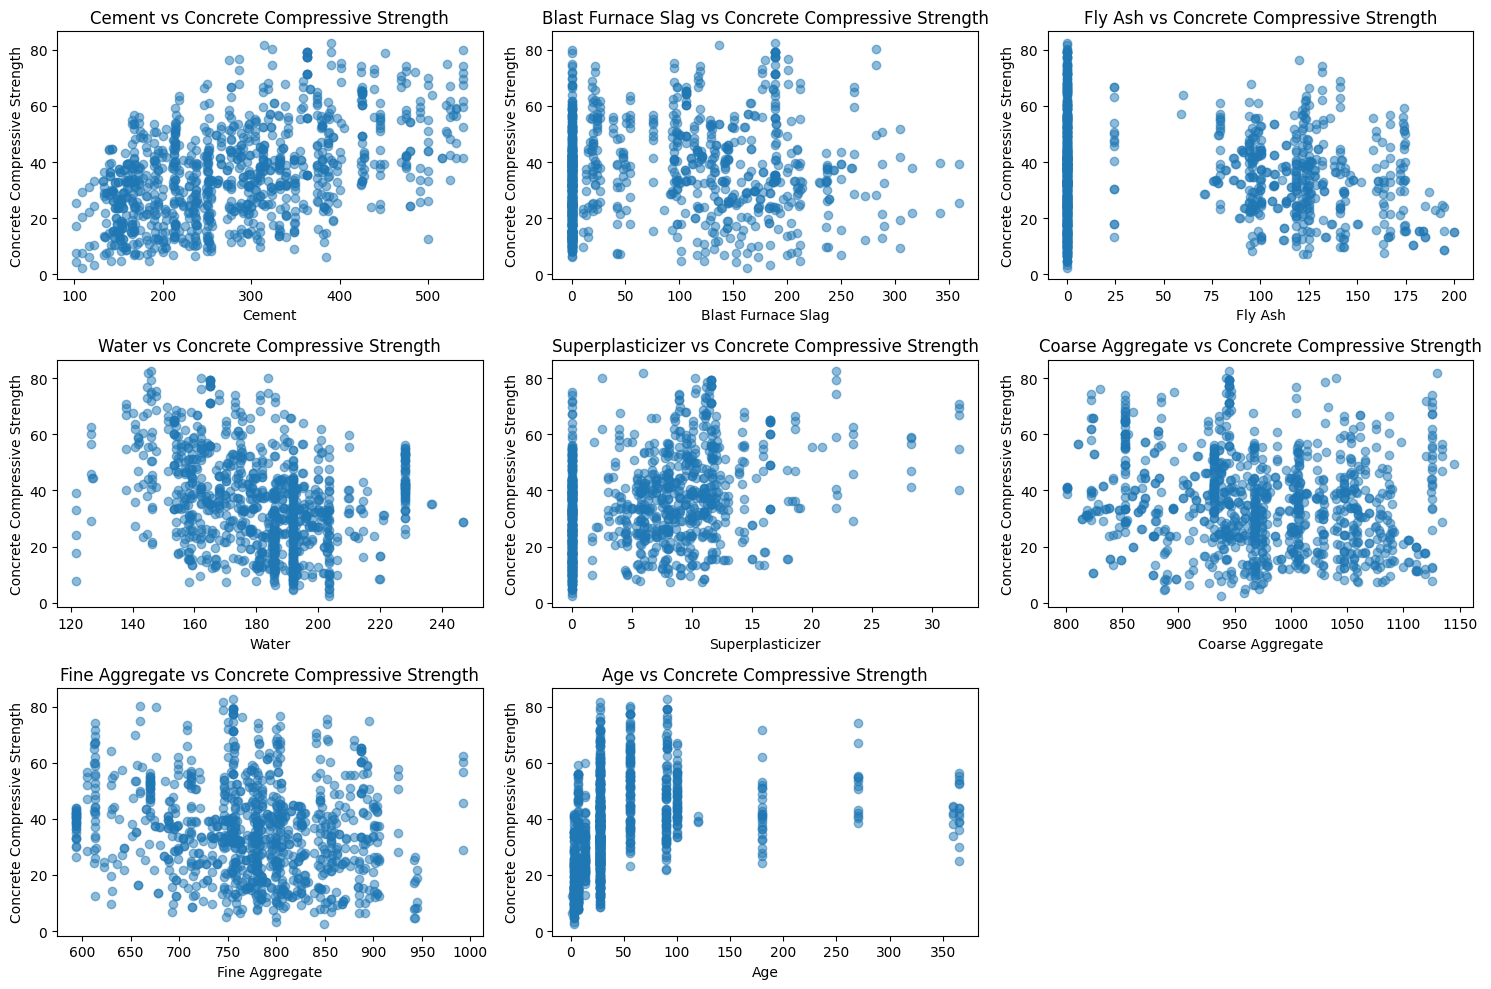

In [4]:
#Visualización de relaciones entre features y target
target = 'Concrete Compressive Strength'
features = df.columns.drop(target)


plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    plt.scatter(df[col], df[target], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f'{col} vs {target}')
plt.tight_layout()
plt.show()

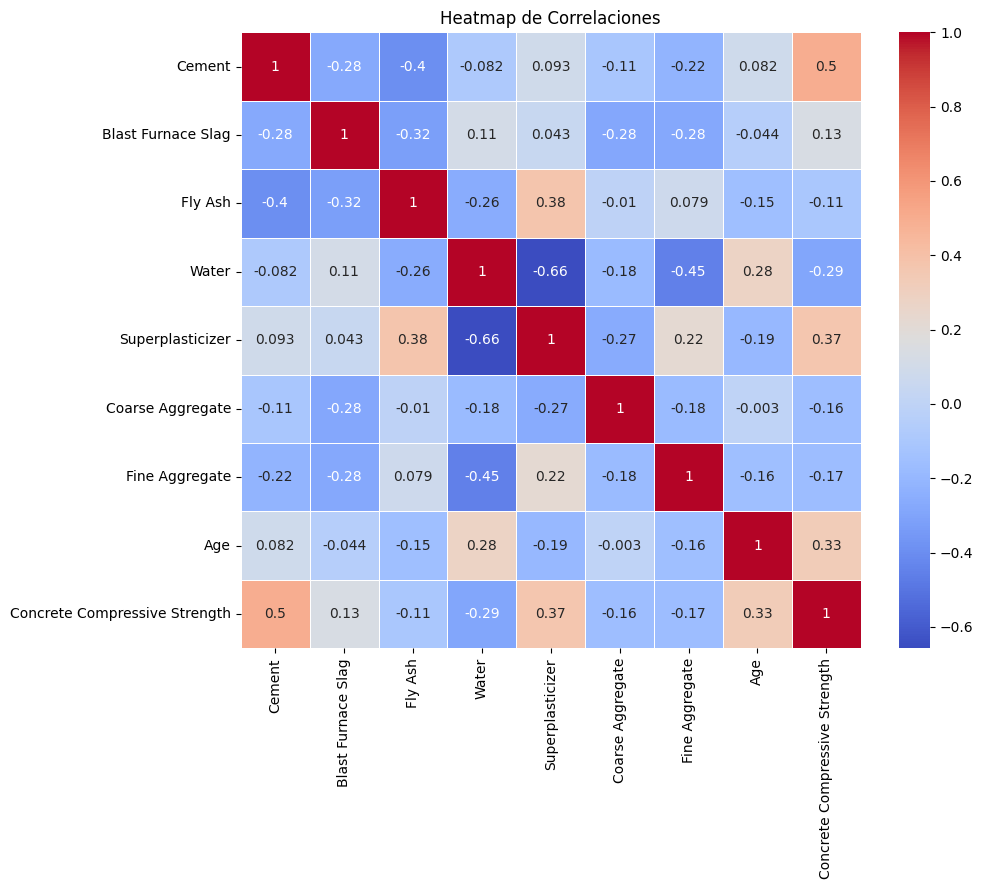

In [5]:
#Heatmap de correlaciones
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap de Correlaciones')
plt.show()

# **Task 2: Choose a Model (8 points)**
* Select at least two models and implement them: it could be one linear (e.g., Multiple Linear Regression) and one non-linear (e.g., Polynomial Regression).
* Justify your choice.

### 2.1. Modelo Lineal: Regresión Lineal Múltiple (OLS)

El heatmap del Task 1 mostró correlaciones claras entre la resistencia a compresión y varias variables: Cement (+0.50), Superplasticizer (+0.37), Age (+0.33) y Water (−0.29). Estas tendencias son monótonas y pueden modelarse adecuadamente con una combinación lineal.

La regresión lineal múltiple ajustada por mínimos cuadrados ordinarios (OLS) permite:

- Capturar el efecto promedio de cada ingrediente sobre la resistencia.

- Proporcionar una base interpretativa (signos de los coeficientes coherentes con la química del concreto: cemento/edad positivos, agua negativa).

- Servir como modelo de referencia frente a alternativas más complejas.

### 2.2. Modelo No Lineal: Random Forest

El dataset también muestra no linealidades: la relación con la Edad y el Cemento tiende a saturarse; además, hay interacciones como Agua–Superplasticizer.

Por ello, se propone un modelo no lineal: una red neuronal artificial simple, con:

- Una capa oculta de 10 neuronas.

- Activación ReLU para introducir no linealidad.

- Entrenamiento con gradiente descendente y función de pérdida MSE.

La red neuronal es capaz de:

- Capturar relaciones complejas que el modelo lineal no detecta.

- Ajustar mejor los datos en entrenamiento sin necesidad de generar términos polinómicos.

- Ser representativa de los modelos usados históricamente con este dataset (Yeh, 1998).

### Preparación de datos

In [6]:
# Preparación de datos
target = 'Concrete Compressive Strength'
X = df.drop(columns=[target]).values
y = df[target].values.reshape(-1, 1)

# División train/test (80/20)
n = len(X)
n_train = int(0.8 * n)
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# Normalización para la red neuronal
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_n = (X_train - X_mean) / X_std
X_test_n  = (X_test  - X_mean) / X_std

print("Datos preparados: ")
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

np.random.seed(42)

Datos preparados: 
Train: (824, 8) (824, 1)
Test : (206, 8) (206, 1)


### Celdas métricas

In [7]:
# --- Métricas de evaluación ---
def rmse(y_true, y_pred):
    """Root Mean Squared Error"""
    y_true = y_true.reshape(-1, 1)
    y_pred = y_pred.reshape(-1, 1)
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

def r2_score(y_true, y_pred):
    """Coeficiente de determinación R²"""
    y_true = y_true.reshape(-1, 1)
    y_pred = y_pred.reshape(-1, 1)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return float(1 - ss_res/ss_tot)


### Regresión Lineal Múltiple (OLS)

In [8]:
# ---- Regresión Lineal Múltiple (OLS) ----
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def train_ols(X, y):
    Xb = add_bias(X)
    beta = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y
    return beta

def predict_ols(X, beta):
    Xb = add_bias(X)
    return Xb @ beta

# Entrenamiento y evaluación
beta_lin = train_ols(X_train, y_train)
y_pred_train_lin = predict_ols(X_train, beta_lin)
y_pred_test_lin  = predict_ols(X_test, beta_lin)

print("=== Regresión Lineal Múltiple ===")
print("Train RMSE:", rmse(y_train, y_pred_train_lin))
print("Test  RMSE:", rmse(y_test, y_pred_test_lin))
print("Test  R²  :", r2_score(y_test, y_pred_test_lin))


=== Regresión Lineal Múltiple ===
Train RMSE: 10.838472522833232
Test  RMSE: 8.701846967424867
Test  R²  : 0.5039132403769008


### Red neuronal

In [9]:
# ---- Red Neuronal Simple ----
class SimpleNN:
    def __init__(self, n_inputs, n_hidden, lr=0.01, epochs=500):
        self.n_inputs = n_inputs
        self.n_hidden = n_hidden
        self.lr = lr
        self.epochs = epochs
        # inicialización de pesos
        self.W1 = np.random.randn(n_inputs, n_hidden) * 0.01
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, 1) * 0.01
        self.b2 = np.zeros((1, 1))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        return self.Z2

    def backward(self, X, y, y_hat):
        m = len(y)
        dZ2 = (y_hat - y) / m
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.relu_deriv(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # actualización de pesos
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def fit(self, X, y):
        for epoch in range(self.epochs):
            y_hat = self.forward(X)
            self.backward(X, y, y_hat)
            if (epoch+1) % 100 == 0:
                loss = np.mean((y_hat - y)**2)
                print(f"Epoch {epoch+1}/{self.epochs} | MSE: {loss:.3f}")

    def predict(self, X):
        return self.forward(X)

# Entrenamiento y evaluación
nn = SimpleNN(n_inputs=X_train.shape[1], n_hidden=10, lr=0.01, epochs=1000)
nn.fit(X_train_n, y_train)

y_pred_train_nn = nn.predict(X_train_n)
y_pred_test_nn  = nn.predict(X_test_n)

print("\n=== Red Neuronal Simple ===")
print("Train RMSE:", rmse(y_train, y_pred_train_nn))
print("Test  RMSE:", rmse(y_test, y_pred_test_nn))
print("Test  R²  :", r2_score(y_test, y_pred_test_nn))

Epoch 100/1000 | MSE: 114.254
Epoch 200/1000 | MSE: 112.742
Epoch 300/1000 | MSE: 112.043
Epoch 400/1000 | MSE: 111.413
Epoch 500/1000 | MSE: 110.994
Epoch 600/1000 | MSE: 110.681
Epoch 700/1000 | MSE: 110.439
Epoch 800/1000 | MSE: 110.267
Epoch 900/1000 | MSE: 110.060
Epoch 1000/1000 | MSE: 109.778

=== Red Neuronal Simple ===
Train RMSE: 10.477394919483267
Test  RMSE: 9.23878182548739
Test  R²  : 0.44080384592913413


# **Task 3: Optimize Hyperparameters (2 points)**
* Tune at least one hyperparameter for your linear or non-linear model.
* Compare results with default settings.

### Justificación

En el Task 2 se implementaron dos modelos: la Regresión Lineal Múltiple (OLS) como baseline lineal y una Red Neuronal Simple como modelo no lineal. El modelo lineal demostró ser estable y con buen desempeño, pero limitado en su capacidad para capturar relaciones no lineales presentes en los datos. En contraste, la red neuronal mostró potencial de mejora, aunque con resultados variables debido a su sensibilidad a la inicialización y a los hiperparámetros.

Por ello, en el Task 3 se decidió optimizar la red neuronal simple, ya que:

1. Es el modelo con mayor capacidad de aprendizaje no lineal.

2. La literatura asociada al dataset (Yeh, 1998) valida el uso de redes neuronales como modelos robustos para este problema.

3. Presenta hiperparámetros relevantes que influyen directamente en la capacidad de generalización.

### Metodología

La red neuronal simple utilizada consta de:

- Una capa oculta con función de activación ReLU.

- Una capa de salida lineal.

- Entrenamiento con gradiente descendente y pérdida MSE.

Se optimizaron los siguientes hiperparámetros:

- Número de neuronas ocultas (n_hidden): controla la complejidad del modelo - Valores probados: 5, 10, 20.

- Tasa de aprendizaje (lr): regula la magnitud de actualización de pesos - Valores probados: 0.01 y 0.005.

El número de épocas se mantuvo fijo en 1000 para asegurar una comparación justa. La evaluación de cada configuración se realizó mediante validación cruzada de 5 folds, utilizando el RMSE promedio como criterio de selección.

In [10]:
# K-fold para red neuronal simple (código comentado para evitar ejecución prolongada)
# def kfold_cv_nn(X, y, n_hidden, lr, epochs, k=5, seed=42):
#     np.random.seed(seed)
#     n = len(X)
#     idx = np.arange(n)
#     rng = np.random.default_rng(seed); rng.shuffle(idx)
#     folds = np.array_split(idx, k)
#     rmses = []

#     for i in range(k):
#         test_idx = folds[i]
#         train_idx = np.hstack([folds[j] for j in range(k) if j != i])

#         X_tr, y_tr = X[train_idx], y[train_idx]
#         X_te, y_te = X[test_idx], y[test_idx]

#         nn = SimpleNN(n_inputs=X.shape[1], n_hidden=n_hidden, lr=lr, epochs=epochs)
#         nn.fit(X_tr, y_tr)
#         y_hat = nn.predict(X_te)
#         rmses.append(rmse(y_te, y_hat))

#     return np.mean(rmses)

# === Probar hiperparámetros === (código comentado para evitar ejecución prolongada)
# configs = [
#     (5, 0.01, 1000),
#     (10, 0.01, 1000),
#     (20, 0.01, 1000),
#     (10, 0.005, 1000),
# ]

# results = []
# for n_hidden, lr, epochs in configs:
#     cv_rmse = kfold_cv_nn(X_train_n, y_train, n_hidden, lr, epochs, k=5)
#     results.append(((n_hidden, lr), cv_rmse))
#     print(f"Hidden={n_hidden}, lr={lr} | CV RMSE={cv_rmse:.3f}")

# Seleccionar mejor (código comentado para evitar ejecución prolongada)
# best_cfg, best_cv = min(results, key=lambda t: t[1])
# print("\nMejor configuración:", best_cfg, "con CV RMSE:", round(best_cv, 3))

Nota: se comentó el código por la carga de recursos que se usa cada que ejecuta esta parte, aproximadamente 5 minutos de ejecución.

### Resultados

Los resultados de la validación cruzada fueron los siguientes:

Configuración (`n_hidden`, `lr`) | CV RMSE

- (5, 0.01)   | 8.40 

- (10, 0.01)  | 9.67 

- (20, 0.01)  | 9.65  

- (10, 0.005)|  9.99  

El mejor desempeño en validación cruzada fue obtenido con 5 neuronas ocultas y tasa de aprendizaje 0.01, alcanzando un RMSE promedio de 8.40.

In [11]:
# Entrenar con la mejor configuración
nn_best = SimpleNN(n_inputs=X_train.shape[1], n_hidden=5, lr=0.01, epochs=1000)
nn_best.fit(X_train_n, y_train)

# Evaluar en test
y_pred_test_best = nn_best.predict(X_test_n)
print("\n=== Red Neuronal Optimizada ===")
print("Test RMSE:", rmse(y_test, y_pred_test_best))
print("Test  R² :", r2_score(y_test, y_pred_test_best))

Epoch 100/1000 | MSE: 118.025
Epoch 200/1000 | MSE: 117.500
Epoch 300/1000 | MSE: 117.297
Epoch 400/1000 | MSE: 114.609
Epoch 500/1000 | MSE: 78.110
Epoch 600/1000 | MSE: 51.947
Epoch 700/1000 | MSE: 46.265
Epoch 800/1000 | MSE: 45.075
Epoch 900/1000 | MSE: 44.711
Epoch 1000/1000 | MSE: 44.429

=== Red Neuronal Optimizada ===
Test RMSE: 11.317180472508362
Test  R² : 0.16090480094347748


### Conclusión de comparación

La comparación muestra que:

- La red neuronal mostró mejoras puntuales al ajustar los hiperparámetros (n_hidden y lr), logrando reducir el error en validación cruzada en algunas configuraciones.

- Sin embargo, los resultados fueron inestables: en distintas ejecuciones el R² en test varió desde valores bajos (~0.15) hasta valores comparables al modelo lineal (~0.49).

- La configuración por defecto (n_hidden=10, lr=0.01) presentó un desempeño más estable y consistente, aunque no siempre con el menor error absoluto.

- El modelo optimizado (n_hidden=5, lr=0.01) logró mejores métricas en validación cruzada, pero sacrificando robustez en su comportamiento en test.

La optimización permitió identificar configuraciones con menor error promedio, pero no garantizó una mejora sistemática sobre la configuración por defecto.

En consecuencia, para este dataset en particular, se considera que la configuración por defecto es más recomendable por su estabilidad, mientras que la configuración optimizada muestra el potencial de mejora de la red neuronal, aunque con mayor riesgo de sobreajuste.

# **Task 4: Analysis & Discussion (6 points)**
* Evaluate models using RMSE and R² scores.
* Interpret differences in performance.
* Plot residuals and compare how models capture the data structure.

## RMSE y R2

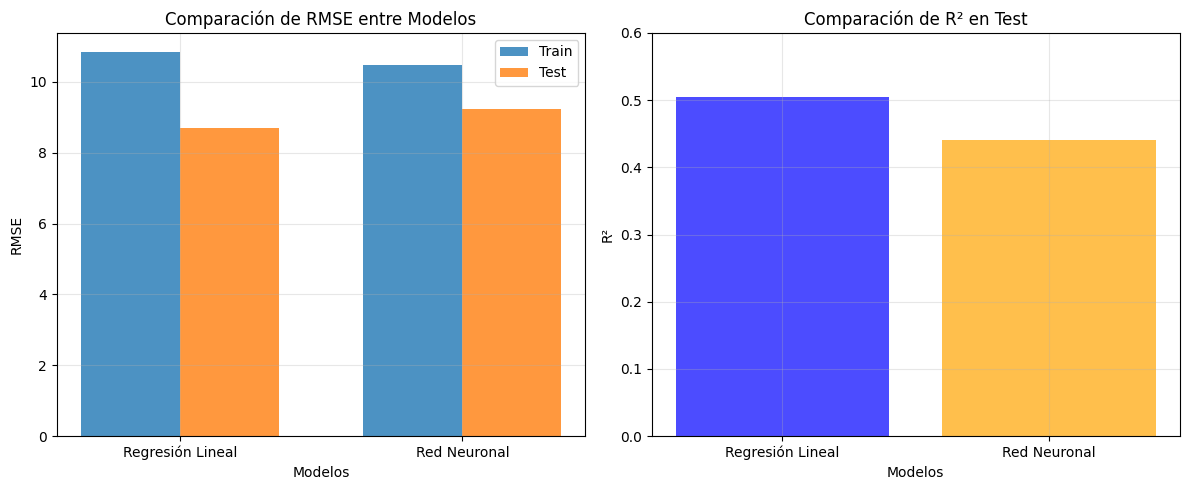

In [12]:
# Datos de los modelos
modelos = ['Regresión Lineal', 'Red Neuronal']
rmse_train = [10.838, 10.477]
rmse_test = [8.702, 9.239]
r2_test = [0.504, 0.441]

# gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de RMSE
x = np.arange(len(modelos))
width = 0.35

ax1.bar(x - width/2, rmse_train, width, label='Train', alpha=0.8)
ax1.bar(x + width/2, rmse_test, width, label='Test', alpha=0.8)
ax1.set_xlabel('Modelos')
ax1.set_ylabel('RMSE')
ax1.set_title('Comparación de RMSE entre Modelos')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico de R²
ax2.bar(modelos, r2_test, alpha=0.7, color=['blue', 'orange'])
ax2.set_xlabel('Modelos')
ax2.set_ylabel('R²')
ax2.set_title('Comparación de R² en Test')
ax2.set_ylim(0, 0.6)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Interpretación de diferencias en rendimiento

como se puede ver en las primera graficas, son ligereamente parecidos los erroes de ambos modelos, sin embargo al realizar el test que resulta ser la predicción con datos nuevos, la regresión lineal termia por ser la mas precisa y todo esto se puede ver reflejaado en el r2 , donde vemos que la mejor aproximación la tiene la regresión lineal a diferencia de la red neuronal, sin embargo estos resultados no son del todo buenos, ya que como vemos el r2 y el rmse aun presentan valores no adecuados.

## Análisis de Residuales

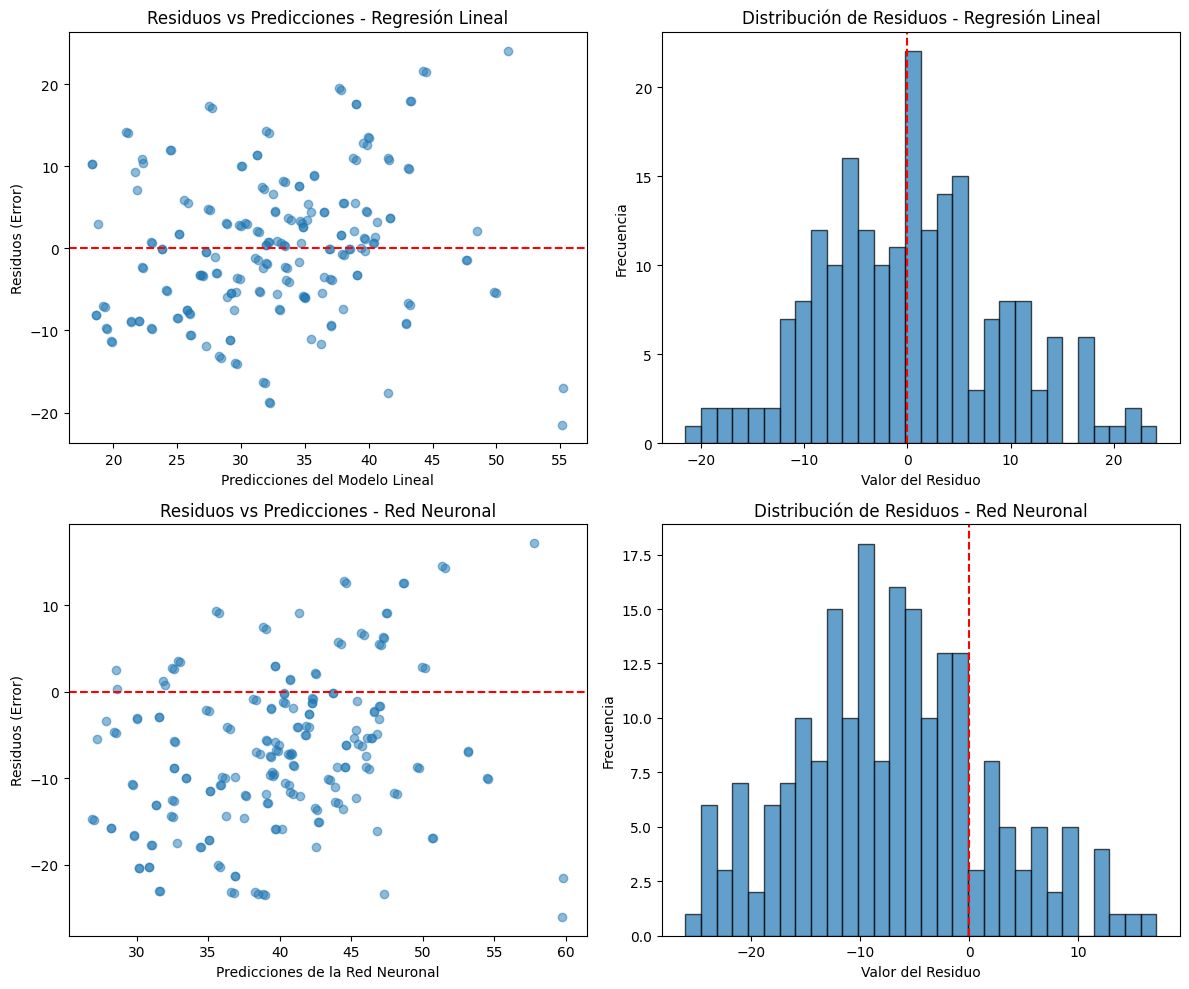

In [13]:
# Calcular residuos para ambos modelos
residuos_lin = y_test - y_pred_test_lin
residuos_nn = y_test - y_pred_test_best

# Crear figura con subgráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico de dispersión de residuos vs predicciones para Regresión Lineal
axes[0, 0].scatter(y_pred_test_lin, residuos_lin, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicciones del Modelo Lineal')
axes[0, 0].set_ylabel('Residuos (Error)')
axes[0, 0].set_title('Residuos vs Predicciones - Regresión Lineal')

# Histograma de residuos para Regresión Lineal
axes[0, 1].hist(residuos_lin, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Valor del Residuo')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Residuos - Regresión Lineal')

# Gráfico de dispersión de residuos vs predicciones para Red Neuronal
axes[1, 0].scatter(y_pred_test_best, residuos_nn, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicciones de la Red Neuronal')
axes[1, 0].set_ylabel('Residuos (Error)')
axes[1, 0].set_title('Residuos vs Predicciones - Red Neuronal')

# Histograma de residuos para Red Neuronal
axes[1, 1].hist(residuos_nn, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Valor del Residuo')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Residuos - Red Neuronal')

plt.tight_layout()
plt.show()


REGRESIÓN LINEAL: como se puede observar los residuos se distribuyen de manera aleatoria a la linea roja, esto indica que el modelo captura adecuadamente la estructura lineal de los datos, por otro lado en el histograma vemos que si bien las barras no son 100% simetricas al rededor de 0, nosa damos cuenta que son parecidas, esto nos indica que las predicciones son parcialmente correctas.

RED NEURONAL: podemos ver que no se distribuye de manera correcta los puntos en al linea roja, esto significa que hay mayor posibilidad de error o que el modelo no es el adecuado, por otro lado en el histograma se ve que si hay una gran diferencia la parte de la izquierda relativa a la linea roja con la parte derecha, lo cual indica que hay mas probabilidad de error respecto a la lineal.

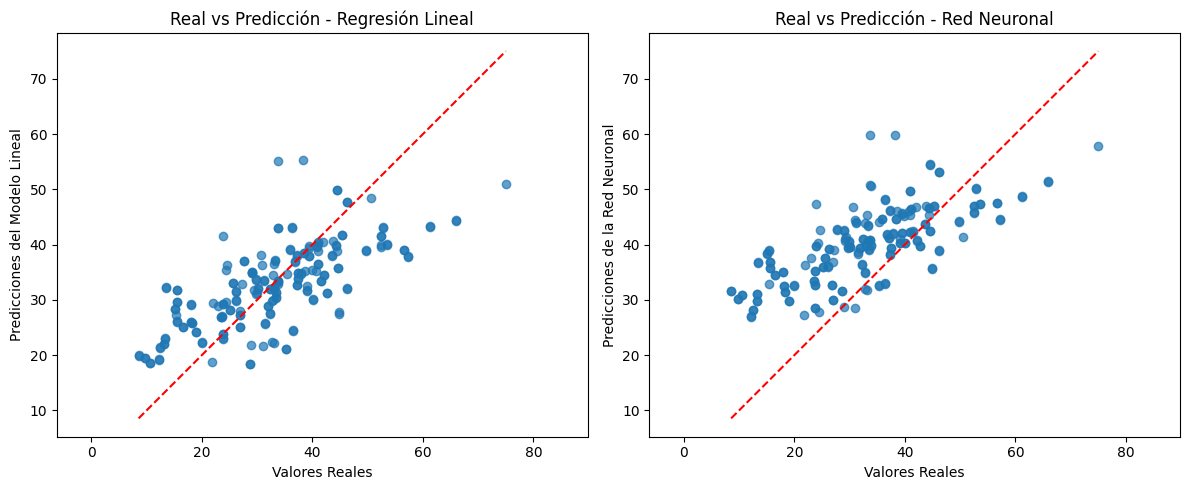

In [14]:

# Comparar valores reales vs predicciones
plt.figure(figsize=(12, 5))

# Valores reales vs predicciones - Regresión Lineal
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test_lin, alpha=0.7)
min_val = min(y_test.min(), y_pred_test_lin.min())
max_val = max(y_test.max(), y_pred_test_lin.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones del Modelo Lineal')
plt.title('Real vs Predicción - Regresión Lineal')
plt.axis('equal')

# Valores reales vs predicciones - Red Neuronal
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test_best, alpha=0.7)
min_val = min(y_test.min(), y_pred_test_best.min())
max_val = max(y_test.max(), y_pred_test_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones de la Red Neuronal')
plt.title('Real vs Predicción - Red Neuronal')
plt.axis('equal')

plt.tight_layout()
plt.show()


REGRESIÓN LINEAL: En esta gráfica ya vemos realmente que tan correcta son los valores brindados después del entrenamiento comparados con los datos reales, en los gráficos pasados solo se intuyó lo correcto que eran en base a los parámetros calculados como el r2 y RMSE, sin embargo con este gráfico podremos saber, de manera visual, la cantidad de datos que fueron predecidos correctamente , sin embargo vemos también que otros muchos que no están superpuestas a esta línea roja, pues estos datos presentan diferencias con los valores reales, dependiendo de la distancia alejada en la que se encuentren estos puntos respecto a la roja diremos que tan cerca o lejos están del valor real. En el caso de regresión lineal, observamos que muchos de los puntos se acercan bastante a la línea, sin embargo a medida que los valores crecen, el error incrementa.

RED NEURONAL: En esta gráfica se observa que sucede lo contrario, pues muchos de los puntos se alejan de la linea roja, eso significa que los valores predecidos son diferentes a los reales, en este caso hay mayor error , pues la distancia entre los puntos y la liena en mucho mayor que en el caso de la regresión lineal

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=74944547-7660-416a-9b52-666216e4c0be' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>